## Section 1: Import Required Libraries

In [941]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.signal import butter, filtfilt, find_peaks, hilbert, spectrogram
from scipy.stats import skew, kurtosis
import seaborn as sns
from pathlib import Path
import warnings
import re
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
warnings.filterwarnings('ignore')
from scipy.signal import hilbert
from scipy.fft import rfft, rfftfreq
# Setup plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [942]:
# Define dataset paths
BASE_PATH = Path('/home/foxcoon/Uppsala/Postdoc assignment')

# Dataset 1
dataset1_path = BASE_PATH / 'Dataset 1'
dataset1_txt = dataset1_path / 'CH4 LFP-Gr Plating 2026-01-21.txt'
dataset1_raw_dir = dataset1_path / 'Raw CH4 LFP-Gr Plating 2026-01-21'

# # Dataset 1
# dataset1_path = BASE_PATH / 'Dataset 2'
# dataset1_txt = dataset1_path / 'CH2 LFP-Gr Plating 2026-02-19.txt'
# dataset1_raw_dir = dataset1_path / 'Raw CH2 LFP-Gr Plating 2026-02-19'

print("Dataset 1 path:", dataset1_path)
# print("Dataset 2 path:", dataset2_path)
print(f"Dataset 1 has {len(list(dataset1_raw_dir.glob('rawAE_1_*.csv')))} AE events")
# print(f"Dataset 2 has {len(list(dataset2_raw_dir.glob('rawAE_1_*.csv')))} AE events")

Dataset 1 path: /home/foxcoon/Uppsala/Postdoc assignment/Dataset 1
Dataset 1 has 1552 AE events


## Section 2: Load Dataset Metadata and Summary Files

In [943]:
def load_measurement_data(txt_file_path):
    """Load tab-separated measurement summary file."""
    with open(txt_file_path, 'r', encoding='cp949', errors='ignore') as f:
        # First line: cell description
        description = f.readline().strip()
        # Second line: blank or header separator
        f.readline()
        # Third line onwards: data with headers
        df = pd.read_csv(f, sep='\t')
    return df, description

def drop_all_na_columns(df):
    """Drop columns that are entirely NaN."""
    return df.dropna(axis=1, how='all')

# Load both datasets
df1, desc1 = load_measurement_data(dataset1_txt)
df1 = drop_all_na_columns(df1)
df1 = df1.dropna(axis=1, how="any")
df1["us"] = (df1["TT [h]"] * 3600 * 1e6).astype(int)
# df1.drop('TT [h]', axis=1, inplace=True)
print("Dataset 1 Description:")
print(desc1)
print("\nDataset 1 Metadata:")
print(df1.head())
print(f"\nShape: {df1.shape}")
print(f"\nColumns: {df1.columns.tolist()}")

Dataset 1 Description:
Fresh cell assembled LFP 16mm 1.0 mAh/cm2 Graphite 13mm 1.2 mAh/cm2 18mm Celgard 2325 and 16mm GF/A LP40 60킠 1x C/5 extended cutoff voltage

Dataset 1 Metadata:
     TT [h]    U [V]  Z1 []         us
0  0.000000  0.21514      0          0
1  0.016675  0.21460      0   60029999
2  0.033347  0.21418      0  120049200
3  0.050031  0.21379      0  180111600
4  0.066711  0.21328      0  240159600

Shape: (1392, 4)

Columns: ['TT [h]', 'U [V]', 'Z1 []', 'us']


## Section 3: Load Raw AE Event Waveform Files

In [944]:
def load_waveform(csv_path):
    """Load a single AE waveform file."""
    df = pd.read_csv(csv_path)
    return df['Time (s)'].values, df['Amplitude (V)'].values

def bandpass_filter(amplitude, time, fs= 10e6, lowcut=20000, highcut=2e6, order=4):
    nyq = fs / 2.0
    
    low = lowcut / nyq
    high = highcut / nyq
    
    b, a = butter(order, [low, high], btype='band')
    
    filtered = filtfilt(b, a, amplitude)
    return filtered

def load_all_waveforms(raw_dir,filter=False, lowcut=20000, highcut=2e6, limit=None):
    """Load all waveforms from a directory."""
    csv_files = sorted(glob.glob(str(raw_dir / 'rawAE_1_*.csv')))
    nums_sorted = sorted(
        int(re.search(r'rawAE_1_(\d+)\.csv$', p).group(1))
        for p in csv_files
    )
    csv_files = []
    for num in nums_sorted:
        csv_files.append(str(raw_dir / f'rawAE_1_{num}.csv'))

    if limit:
        csv_files = csv_files[:limit]
    
    waveforms = {}
    for csv_path in csv_files:
        filename = os.path.basename(csv_path)
        try:
            time, amplitude = load_waveform(csv_path)
            if filter:
                amplitude = bandpass_filter(amplitude, time, lowcut=lowcut, highcut=highcut)
            waveforms[filename] = {'time': time, 'amplitude': amplitude}
        except Exception as e:
            print(f"Error loading {filename}: {e}")
    
    return waveforms # ['filename' :{'time': time, 'amplitude': amplitude}, ...]

In [945]:
# Load a sample of waveforms from Dataset 1 for exploration
print("Loading sample waveforms from Dataset 1...")
lowcut = 100000  # 100 kHz
highcut = 2e6   # 2 MHz
waveforms_d1 = load_all_waveforms(dataset1_raw_dir, filter=False, lowcut=lowcut, highcut=highcut)


Loading sample waveforms from Dataset 1...


In [946]:

val_lst = []
for waveform in waveforms_d1:
    val = waveforms_d1[waveform]['amplitude']
    val_lst.append(val)
val_lst = np.array(val_lst).reshape(-1)

In [947]:
val_lst = np.abs(val_lst)
val_lst.sort()
print(val_lst[val_lst != 0])

[7.60000e-05 7.60000e-05 7.60000e-05 ... 3.57971e-01 3.79944e-01
 3.82385e-01]


## Section 4: Visualize Sample Waveforms and Noise Floor

In [948]:
# Load a sample of waveforms from Dataset 1 for exploration
print("Loading sample waveforms from Dataset 1...")
lowcut = 100000  # 100 kHz
highcut = 2e6   # 2 MHz
waveforms_d1 = load_all_waveforms(dataset1_raw_dir, filter=True, lowcut=lowcut, highcut=highcut)
print(f"Loaded {len(waveforms_d1)} waveforms")

Loading sample waveforms from Dataset 1...


Loaded 1552 waveforms


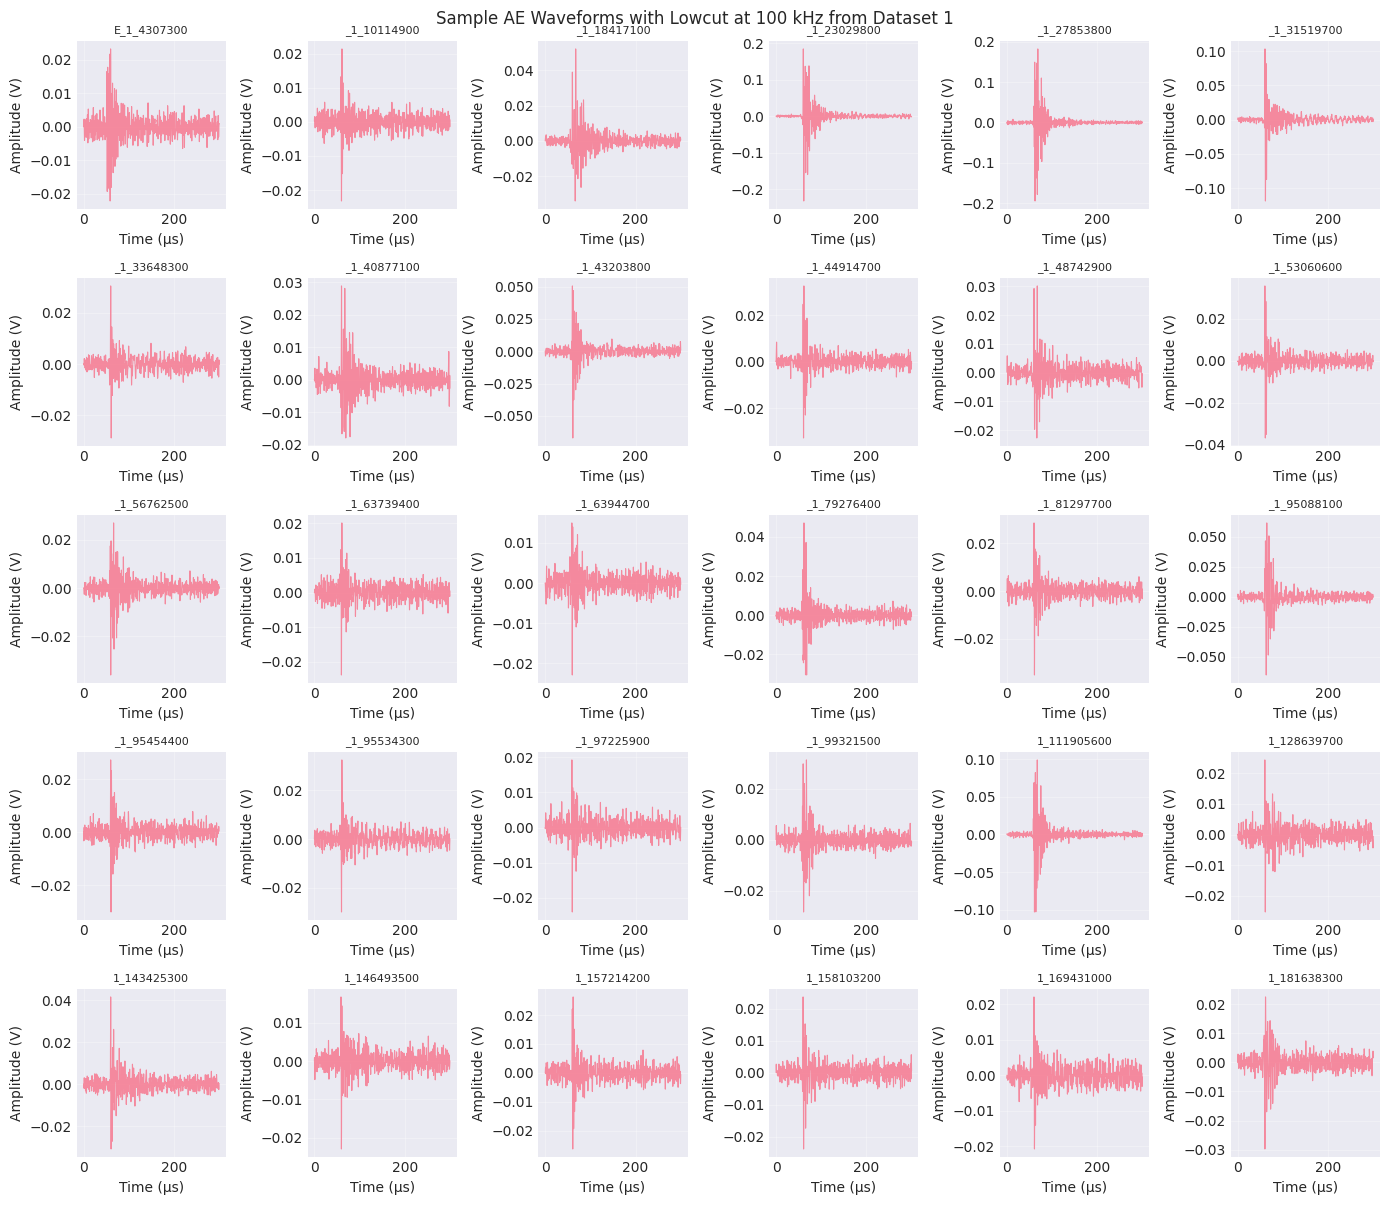

In [949]:
# Visualize a grid of sample waveforms
fig, axes = plt.subplots(5, 6, figsize=(14, 12))
axes = axes.flatten()

wf_list = list(waveforms_d1.items())[:30]
for idx, (filename, wf) in enumerate(wf_list):
    ax = axes[idx]
    time_us = wf['time'] * 1e6  # Convert to microseconds
    ax.plot(time_us, wf['amplitude'], linewidth=0.8, alpha=0.8)
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude (V)')
    ax.set_title(f"{filename[-15:-4]}", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Sample AE Waveforms with Lowcut at 100 kHz from Dataset 1', fontsize=12, y=1.00)
plt.show()

In [950]:
# Load a sample of waveforms from Dataset 1 for exploration
print("Loading sample waveforms from Dataset 1...")
lowcut = 20000  # 20 kHz
highcut = 2e6   # 2 MHz
waveforms_d1 = load_all_waveforms(dataset1_raw_dir, filter=True, lowcut=lowcut, highcut=highcut)
print(f"Loaded {len(waveforms_d1)} waveforms")

Loading sample waveforms from Dataset 1...
Loaded 1552 waveforms


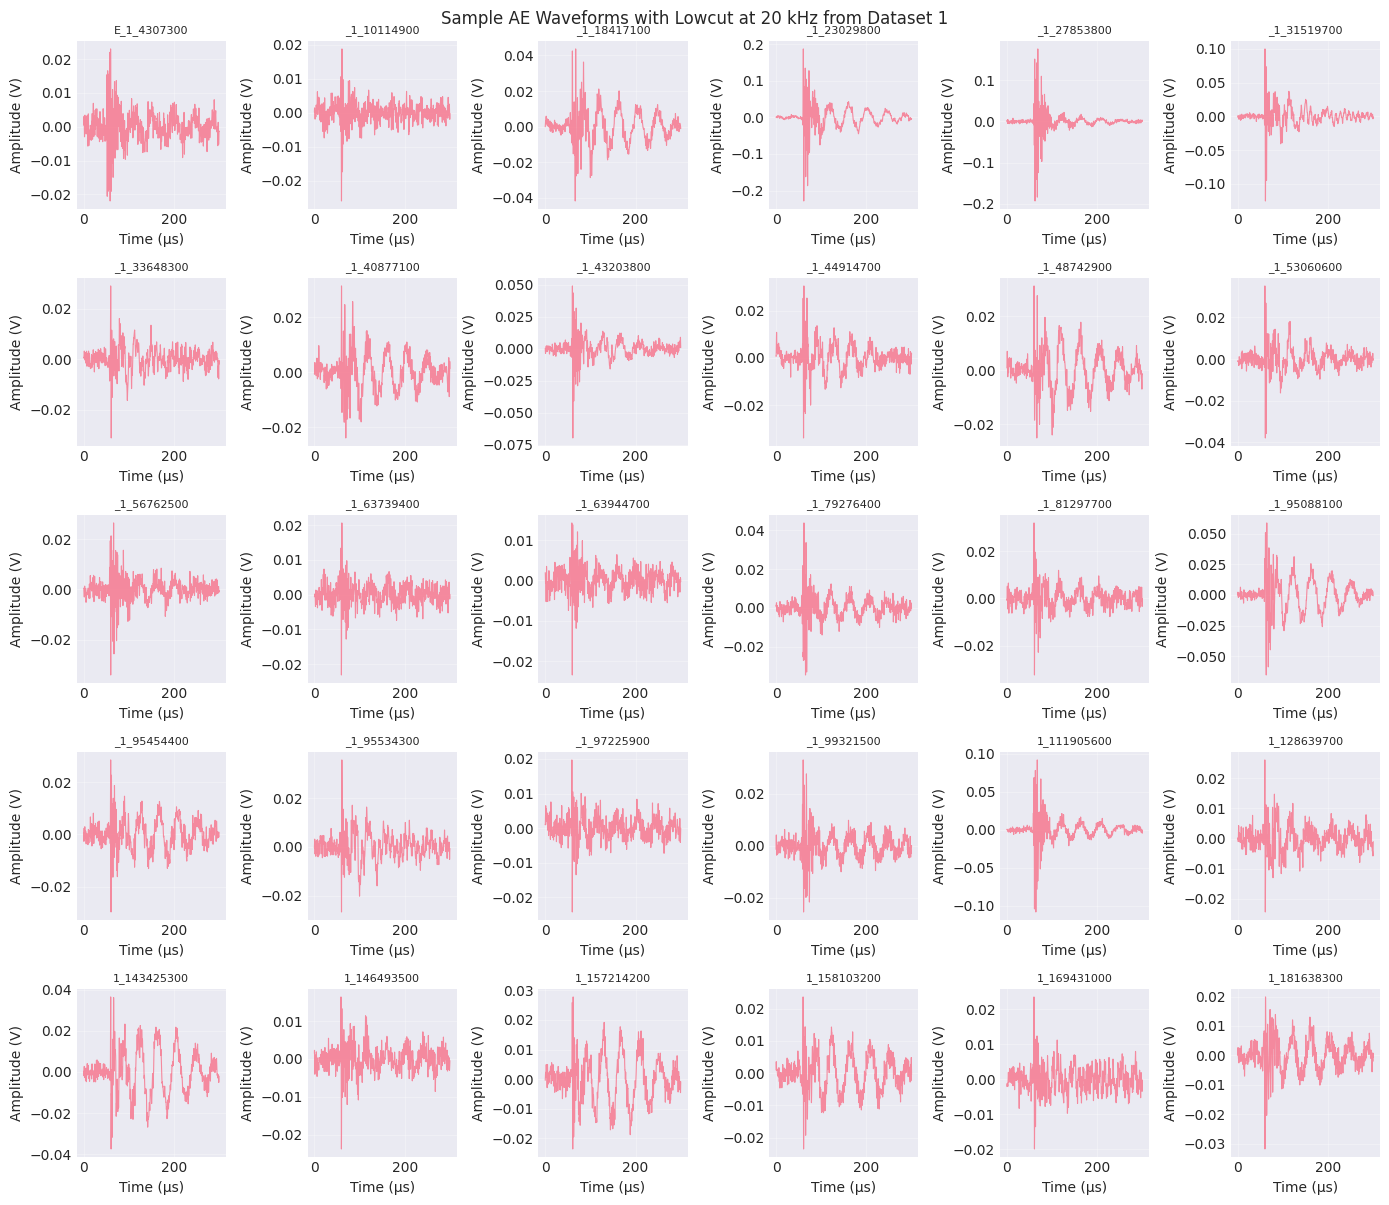

In [951]:
# Visualize a grid of sample waveforms
fig, axes = plt.subplots(5, 6, figsize=(14, 12))
axes = axes.flatten()

wf_list = list(waveforms_d1.items())[:30]
for idx, (filename, wf) in enumerate(wf_list):
    ax = axes[idx]
    time_us = wf['time'] * 1e6  # Convert to microseconds
    ax.plot(time_us, wf['amplitude'], linewidth=0.8, alpha=0.8)
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude (V)')
    ax.set_title(f"{filename[-15:-4]}", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Sample AE Waveforms with Lowcut at 20 kHz from Dataset 1', fontsize=12, y=1.00)
plt.show()

# Reasoning
 - Lowcut should be 20kHz as the higher lowcut removes the important osilation.
 - No baseline correction was applied because some time series exhibited oscillations prior to the event spike, making it difficult to define a stable pre-event baseline.
 - Band-pass filtering was applied according to the literature.

In [952]:
def power_band_finder(waveforms, fs=10e6, band_limits=(20_000, 2_000_000), n_bands=5, mode="equal_power", show_plot=True):
    spectra = []
    freqs_ref = None

    for filename, wf in waveforms.items():
        x = np.asarray(wf["amplitude"], dtype=float)
        freqs = rfftfreq(len(x), d=1/fs)
        spec = np.abs(rfft(x))
        spec_power = spec**2

        mask = (freqs >= band_limits[0]) & (freqs <= band_limits[1])
        if freqs_ref is None:
            freqs_ref = freqs[mask]

        spectra.append(spec_power[mask])

    spectra = np.asarray(spectra)
    mean_spectrum = spectra.mean(axis=0)

    if mode == "equal_width":
        boundaries = np.linspace(freqs_ref[0], freqs_ref[-1], n_bands + 1)

    elif mode == "equal_power":
        cumulative = np.cumsum(mean_spectrum)
        cumulative = cumulative / cumulative[-1]
        targets = np.linspace(0, 1, n_bands + 1)
        boundaries = np.interp(targets, cumulative, freqs_ref)
        boundaries[0] = freqs_ref[0]
        boundaries[-1] = freqs_ref[-1]

    else:
        raise ValueError("mode must be 'equal_width' or 'equal_power'")

    boundaries = np.round(boundaries).astype(int)
    freq_bands = [(int(boundaries[i]), int(boundaries[i+1])) for i in range(len(boundaries)-1)]

    if show_plot:
        plt.figure(figsize=(12, 5))
        plt.plot(freqs_ref / 1e3, mean_spectrum, lw=1.5)
        for b in boundaries:
            plt.axvline(b / 1e3, color="red", ls="--", alpha=0.7)
        plt.xlabel("Frequency (kHz)")
        plt.ylabel("Mean spectral power")
        plt.title(f"Mean AE spectrum with {n_bands} automatic bands ({mode})")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return freq_bands
    


In [953]:
freq_bands = power_band_finder(waveforms_d1, fs=10e6, band_limits=(lowcut, highcut), n_bands=5, mode="equal_width", show_plot=False)
print(freq_bands)

[(20000, 416000), (416000, 812000), (812000, 1208000), (1208000, 1604000), (1604000, 2000000)]


In [954]:
def compute_waveform_stats(amplitude, time, noise_floor =15e-6, fs=10e6, vref=1e-6, amplifier_gain_db=60, detection_threshold_db=27, freq_bands=None):
    x = np.asarray(amplitude)
    t = np.asarray(time)
    amp = x.copy()
    abs_amp = np.abs(amp)
    abs_amp[abs_amp==0] = 1e-12

    peak_idx = np.argmax(abs_amp)
    peak_amp = abs_amp[peak_idx]
    peak_time = t[peak_idx]

    peak_amp_db = 20 * np.log10(peak_amp / vref ) - amplifier_gain_db
    abs_amp_db = 20 * np.log10(abs_amp / vref) - amplifier_gain_db
    noise_floor_db = 20 * np.log10(noise_floor / vref) 
    snr_db = peak_amp_db - noise_floor_db
    detection_threshold_volt = 10**((27 + amplifier_gain_db) / 20) * vref
    above = amp >= detection_threshold_volt

    peak_val = x[peak_idx]
    threshold = peak_val / np.e
    after_peak = x[peak_idx:]
    below = np.where(after_peak <= threshold)[0]

    decay_idx = peak_idx + below[0]
    decay_time = t[decay_idx] - t[peak_idx]

    if np.any(above):
        idx = np.where(above)[0]
        first_idx = idx[0]
        last_idx = idx[-1]
        duration = t[last_idx] - t[first_idx]

        crossings = np.diff(above.astype(int))
        counts = int(np.sum(crossings == 1))
        if above[0]:
            counts = max(counts, 1)

        above_first_peak = np.where(np.arange(len(x)) >= first_idx)[0]
        rise_time = t[peak_idx] - t[first_idx] if peak_idx >= first_idx else np.nan
    else:
        duration = 0.0
        counts = 0
        first_idx = None
        last_idx = None
        rise_time = np.nan
    dt = 1/fs
    energy = np.sum(x**2)*dt

    freqs = rfftfreq(len(x), d=1/fs)
    spec = np.abs(rfft(x))
    peak_frequency = freqs[np.argmax(spec)]

    # Centroid frequency (weighted mean frequency)
    spec_power = spec ** 2
    spec_power_sum = np.sum(spec_power) + 1e-12
    centroid_frequency = np.sum(freqs * spec_power) / spec_power_sum

    # Partial power in user-defined frequency bands
    if freq_bands is None:
        freq_bands = [
            (20000, 50e3),
            (50e3, 100e3),
            (100e3, 200e3),
            (200e3, 500e3),
            (500e3, 1e6),
            (1e6, 2e6)
    ]

    band_powers = {}
    total_power = spec_power_sum

    for f_low, f_high in freq_bands:
        mask = (freqs >= f_low) & (freqs < f_high)
        band_power = np.sum(spec_power[mask])
        # band_powers[f"power_{int(f_low/1e3)}_{int(f_high/1e3)}kHz"] = band_power
        band_powers[f"ratio_{int(f_low/1e3)}_{int(f_high/1e3)}kHz"] = band_power / total_power

    return {
        "decay_time": decay_time,
        "snr_db": snr_db,
        "amplitude": peak_amp,
        "energy": energy,
        "rise_time": rise_time,
        "duration": duration,
        "counts": counts,
        "peak_frequency": peak_frequency,
        "centroid_frequency": centroid_frequency,
        # 'amplitude_db': peak_amp_db,
        # "abs_amplitude": abs_amp,
        # "first_idx": first_idx,
        # "last_idx": last_idx,
        # "peak_idx": peak_idx,
        # "peak_time": peak_time,
        **band_powers
    }

def extract_features(waveforms, freq_bands=None):
    stats_list = []
    for filename, wf in waveforms.items():
        stats = compute_waveform_stats(
            wf["amplitude"],
            wf["time"],
            freq_bands=freq_bands,
            fs=10e6,
            vref=1e-6,
            amplifier_gain_db=60,
            detection_threshold_db=27
        )
        stats["filename"] = filename
        stats_list.append(stats)
    stats_df = pd.DataFrame(stats_list)
    return stats_list, stats_df

stats_list,stats_df = extract_features(waveforms_d1, freq_bands=freq_bands)

# print(f"Peak amplitude (dB) range: {stats_df['amplitude_db'].min():.1f} - {stats_df['amplitude_db'].max():.1f} dBV (ref 1uV)")
print(f"SNR range (dB): {stats_df['snr_db'].min():.1f} - {stats_df['snr_db'].max():.1f} dB")
decay_time_10p = stats_df['decay_time'].quantile(0.10)
snr_threshold_10p = stats_df["snr_db"].quantile(0.10)

SNR range (dB): 0.6 - 28.1 dB


## Section 5: Define Artifact Rejection Criteria

Based on visual inspection and statistical analysis, we define the following criteria for artifact rejection:

### Criteria 1: Electromagnetic interference spikes 
- **Rationale**: Less than three cross-counts (This follows the Espinoza paper)
- **Threshold**: cross < 3

### Criteria 2: Oscillations with an implausibly short decay  
- **Rationale**: Exponential decay 
- **Threshold**: Time from $peak$ to $\frac{peak}{e}$.

### Criteria 3: Near-identical duplicate captures 
- **Rationale**: Cosine similarity of extracted features
- **Threshold**: 10 percentile samples

### Criteria 4: Events with no discernible signal above the noise floor
- **Rationale**: Small SNR 
- **Method**: 10 percentile samples

In [955]:
# Remove electromagnetic interference
counts_less_3= []
for stats in stats_list:
    if stats['counts'] < 3:
        counts_less_3.append(stats['filename'])
print("Number of events with fewer than 3 crossings:", len(counts_less_3))

Number of events with fewer than 3 crossings: 1098


In [956]:
# Remove short decay time events
decay_time_10p_lst = []
for stats in stats_list:
    if stats['decay_time'] < decay_time_10p:
        decay_time_10p_lst.append(stats['filename'])
print("Number of events with short decay times:", len(decay_time_10p_lst))

Number of events with short decay times: 0


In [957]:
feature_cols = [
    "duration",
    "counts",
    "amplitude",
    "rise_time",
    "energy",
    "peak_frequency",
    "snr_db",
    "decay_time",
]

feat_df = stats_df[["filename"] + feature_cols].copy()
feat_df = feat_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

X = feat_df[feature_cols].apply(zscore).fillna(0.0).to_numpy()

cos_sim = 1 - squareform(pdist(X, metric="cosine"))
np.fill_diagonal(cos_sim, 1.0)

threshold = 0.95
pairs = np.argwhere(np.triu(cos_sim >= threshold, 1))

rows = []
for i, j in pairs:
    rows.append({
        "file1": feat_df.loc[i, "filename"],
        "file2": feat_df.loc[j, "filename"],
        "cosine_similarity": float(cos_sim[i, j]),
        "cosine_distance": float(1 - cos_sim[i, j]),
    })

sim_df = pd.DataFrame(rows).sort_values(
    ["cosine_similarity", "cosine_distance"],
    ascending=[False, True]
)
sim_df.head()

,file1,file2,cosine_similarity,cosine_distance
14270,rawAE_1_3584639800.csv,rawAE_1_4701731100.csv,0.999998,0.000002
4948,rawAE_1_646712800.csv,rawAE_1_9207527200.csv,0.999996,0.000004
16285,rawAE_1_4977362300.csv,rawAE_1_27449849200.csv,0.999996,0.000004
14969,rawAE_1_3880895400.csv,rawAE_1_19620168700.csv,0.999994,0.000006
18597,rawAE_1_6892828600.csv,rawAE_1_24173072000.csv,0.999992,0.000008


In [958]:
near_identical_df =  sim_df[sim_df["cosine_similarity"] >= 1-1e-3]
print("Number of near-identical pairs:", len(near_identical_df))
near_identical_files = list(near_identical_df['file2'].unique())
print("Number of near-identical files:", len(near_identical_files))

Number of near-identical pairs: 1135
Number of near-identical files: 248


In [959]:
snr_threshold_10p_lst = []
for stats in stats_list:
    if stats['snr_db'] < snr_threshold_10p:
        snr_threshold_10p_lst.append(stats['filename'])
print("Number of events with low SNR:", len(snr_threshold_10p_lst))
removed_files = list(set(counts_less_3 + decay_time_10p_lst + near_identical_files + snr_threshold_10p_lst))
print("Number of removed files:", len(removed_files))

Number of events with low SNR: 156
Number of removed files: 1123


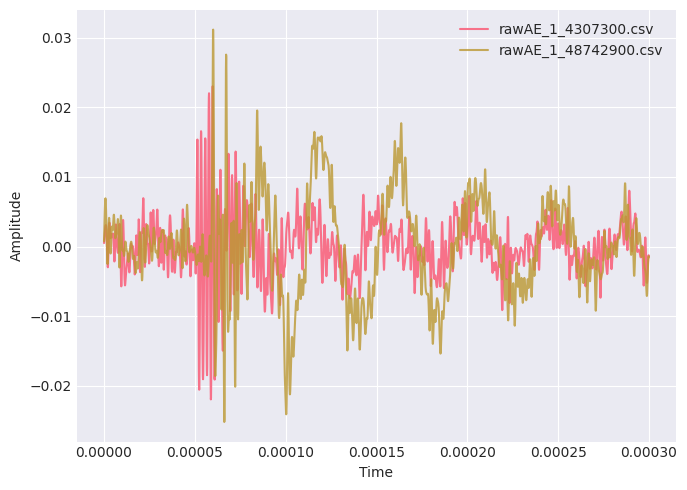

In [960]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

filename1 = sim_df['file1'][0]
filename2 = sim_df['file2'][0]


wf1 = waveforms_d1[filename1]
wf2 = waveforms_d1[filename2]

t1 = np.asarray(wf1["time"])
x1 = np.asarray(wf1["amplitude"])

t2 = np.asarray(wf2["time"])
x2 = np.asarray(wf2["amplitude"])

plt.figure(figsize=(7, 5))
plt.plot(t1, x1, label=filename1)
plt.plot(t2, x2, label=filename2, alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [961]:
waveforms_d1_filtered = {k: v for k, v in waveforms_d1.items() if k not in removed_files}
print(f"Remaining waveforms after filtering: {len(waveforms_d1_filtered)}")
filtered_freq_bands = power_band_finder(waveforms_d1_filtered, fs=10e6, band_limits=(lowcut, highcut), n_bands=5, mode="equal_width", show_plot=False)
print(filtered_freq_bands)
extracted_stats_list, extracted_stats_df = extract_features(waveforms_d1_filtered, freq_bands=filtered_freq_bands)

Remaining waveforms after filtering: 429
[(20000, 416000), (416000, 812000), (812000, 1208000), (1208000, 1604000), (1604000, 2000000)]


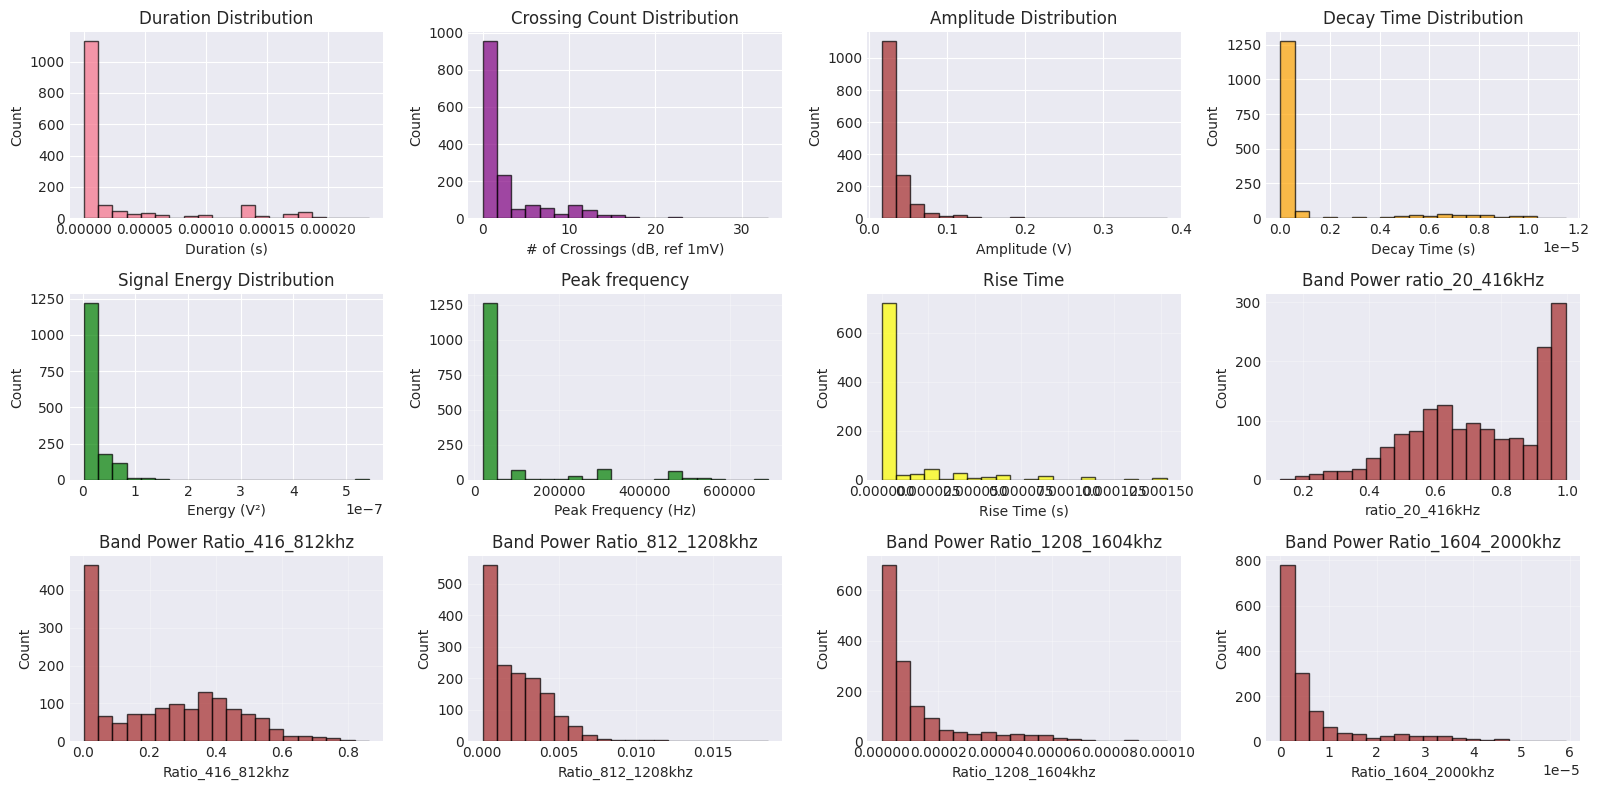

In [962]:
df1_csv = stats_df
power_ratio_1st= [col for col in df1_csv.columns if col.startswith("ratio")][0]
power_ratio = [col for col in df1_csv.columns if col.startswith("ratio")][1:]
# Visualize distributions before data cleaning
fig, axes = plt.subplots(3, 4, figsize=(16, 8))

axes[0, 0].hist(df1_csv['duration'], bins=20, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Duration (s)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Duration Distribution')
axes[0, 0].legend()

axes[0, 1].hist(df1_csv['counts'], bins=20, alpha=0.7, edgecolor='black', color='purple')
axes[0, 1].set_xlabel('# of Crossings (dB, ref 1mV)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Crossing Count Distribution')


axes[0, 2].hist(df1_csv['amplitude'], bins=20, alpha=0.7, edgecolor='black', color='brown')
axes[0, 2].set_xlabel('Amplitude (V)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Amplitude Distribution')

axes[0, 3].hist(df1_csv['decay_time'], bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[0, 3].set_xlabel('Decay Time (s)')
axes[0, 3].set_ylabel('Count')
axes[0, 3].set_title('Decay Time Distribution')

axes[1, 0].hist(df1_csv['energy'], bins=20, alpha=0.7, edgecolor='black', color='green')
axes[1, 0].set_xlabel('Energy (V²)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Signal Energy Distribution')

axes[1, 1].hist(df1_csv['peak_frequency'], bins=20, alpha=0.7, edgecolor='black', color='green')
axes[1, 1].set_xlabel('Peak Frequency (Hz)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Peak frequency')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(df1_csv['rise_time'], bins=20, alpha=0.7, edgecolor='black', color='yellow')
axes[1, 2].set_xlabel('Rise Time (s)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Rise Time')
axes[1, 2].grid(True, alpha=0.3)

axes[1, 3].hist(df1_csv[power_ratio_1st], bins=20, alpha=0.7, edgecolor='black', color='brown')
axes[1, 3].set_xlabel(power_ratio_1st)
axes[1, 3].set_ylabel('Count')
axes[1, 3].set_title(f'Band Power {power_ratio_1st}')
axes[1, 3].grid(True, alpha=0.3)

for i, pr in enumerate(power_ratio):
    axes[2, i].hist(df1_csv[pr], bins=20, alpha=0.7, edgecolor='black', color='brown')
    axes[2, i].set_xlabel(f'{pr.capitalize()}')
    axes[2, i].set_ylabel('Count')
    axes[2, i].set_title(f'Band Power {pr.capitalize()}')
    axes[2, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


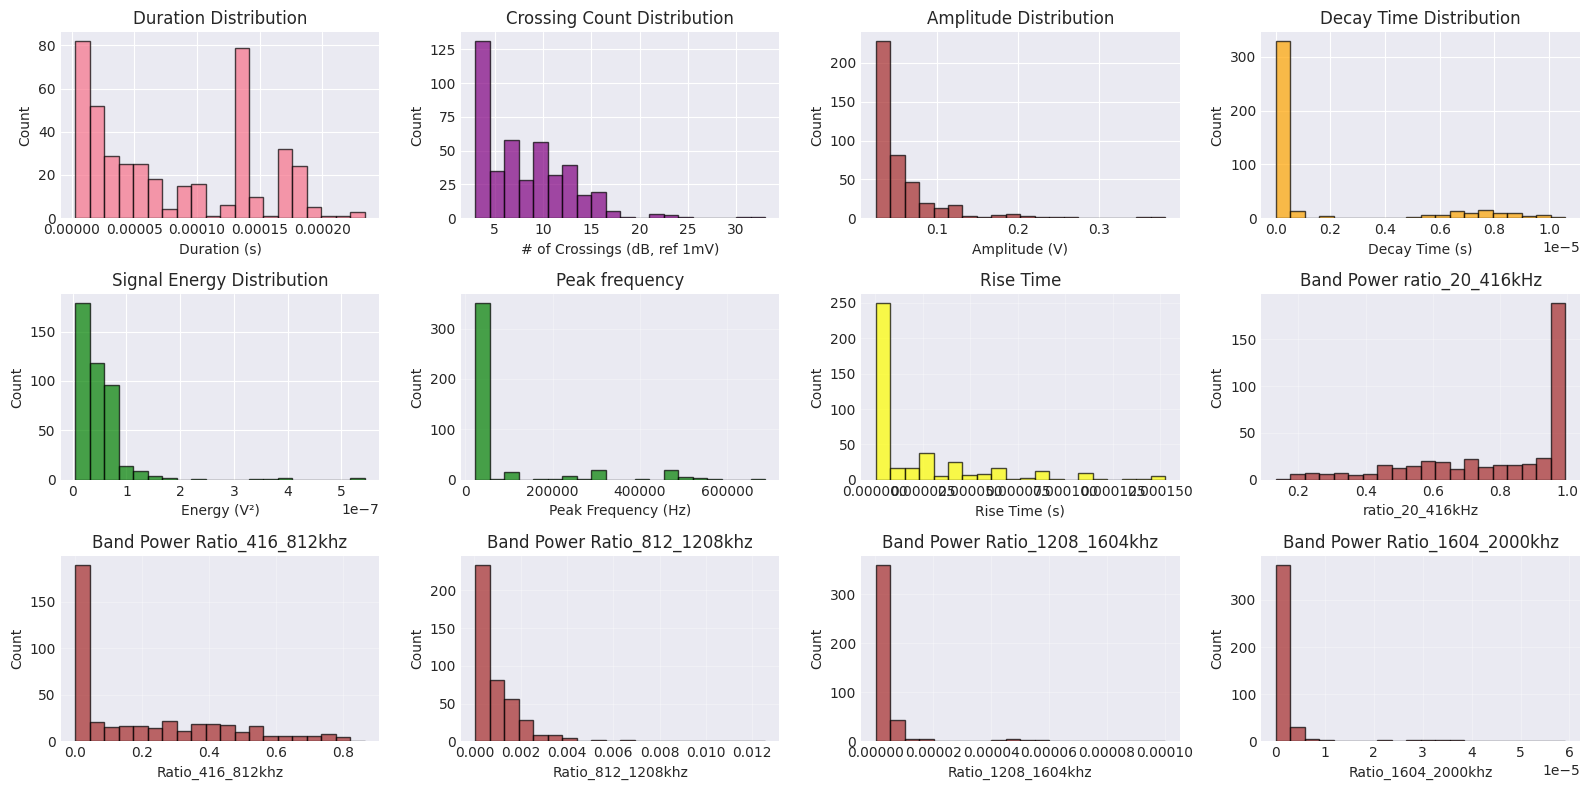

In [963]:
df1_csv = extracted_stats_df
power_ratio_1st= [col for col in df1_csv.columns if col.startswith("ratio")][0]
power_ratio = [col for col in df1_csv.columns if col.startswith("ratio")][1:]
# Visualize distributions before data cleaning
fig, axes = plt.subplots(3, 4, figsize=(16, 8))

axes[0, 0].hist(df1_csv['duration'], bins=20, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Duration (s)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Duration Distribution')
axes[0, 0].legend()

axes[0, 1].hist(df1_csv['counts'], bins=20, alpha=0.7, edgecolor='black', color='purple')
axes[0, 1].set_xlabel('# of Crossings (dB, ref 1mV)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Crossing Count Distribution')


axes[0, 2].hist(df1_csv['amplitude'], bins=20, alpha=0.7, edgecolor='black', color='brown')
axes[0, 2].set_xlabel('Amplitude (V)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Amplitude Distribution')

axes[0, 3].hist(df1_csv['decay_time'], bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[0, 3].set_xlabel('Decay Time (s)')
axes[0, 3].set_ylabel('Count')
axes[0, 3].set_title('Decay Time Distribution')

axes[1, 0].hist(df1_csv['energy'], bins=20, alpha=0.7, edgecolor='black', color='green')
axes[1, 0].set_xlabel('Energy (V²)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Signal Energy Distribution')

axes[1, 1].hist(df1_csv['peak_frequency'], bins=20, alpha=0.7, edgecolor='black', color='green')
# axes[1, 1].scatter(df1_csv['peak_frequency'], df1_csv['snr_db'], alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Peak Frequency (Hz)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Peak frequency')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(df1_csv['rise_time'], bins=20, alpha=0.7, edgecolor='black', color='yellow')
axes[1, 2].set_xlabel('Rise Time (s)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Rise Time')
axes[1, 2].grid(True, alpha=0.3)

axes[1, 3].hist(df1_csv[power_ratio_1st], bins=20, alpha=0.7, edgecolor='black', color='brown')
axes[1, 3].set_xlabel(power_ratio_1st)
axes[1, 3].set_ylabel('Count')
axes[1, 3].set_title(f'Band Power {power_ratio_1st}')
axes[1, 3].grid(True, alpha=0.3)

for i, pr in enumerate(power_ratio):
    axes[2, i].hist(df1_csv[pr], bins=20, alpha=0.7, edgecolor='black', color='brown')
    axes[2, i].set_xlabel(f'{pr.capitalize()}')
    axes[2, i].set_ylabel('Count')
    axes[2, i].set_title(f'Band Power {pr.capitalize()}')
    axes[2, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [964]:
df1_csv["us"] = df1_csv["filename"].str.extract(r'rawAE_1_(\d+)\.csv').astype(int)
# df1_csv = df1_csv.set_index("file_num")
df1_csv.drop(['decay_time', 'snr_db'], axis=1, inplace=True)
df1_csv.head()

,amplitude,energy,rise_time,duration,counts,peak_frequency,centroid_frequency,ratio_20_416kHz,ratio_416_812kHz,ratio_812_1208kHz,ratio_1208_1604kHz,ratio_1604_2000kHz,filename,us
0,0.043637,2.359934e-08,7.600000e-06,0.000025,4,23333.333333,152413.606474,0.858025,0.138626,0.001595,1.032139e-06,6.527155e-07,rawAE_1_18417100.csv,18417100
1,0.228690,2.377896e-07,1.500000e-06,0.000183,33,23333.333333,288197.236324,0.511482,0.487764,0.000632,6.179570e-07,4.249000e-07,rawAE_1_23029800.csv,23029800
2,0.193455,1.388852e-07,2.500000e-06,0.000031,17,406666.666667,481767.080035,0.270816,0.727675,0.001223,6.671493e-07,3.193677e-07,rawAE_1_27853800.csv,27853800
3,0.125491,5.281190e-08,1.500000e-06,0.000092,13,26666.666667,270114.368530,0.644069,0.354702,0.001045,4.046020e-07,2.019425e-07,rawAE_1_31519700.csv,31519700
4,0.031343,1.243363e-08,2.000000e-07,0.000025,3,23333.333333,143677.958354,0.889901,0.107078,0.001540,2.794179e-06,1.432612e-06,rawAE_1_40877100.csv,40877100


In [965]:
max_file = df1_csv['us'].max()
max_tt = df1['us'].max()
outs = df1_csv[df1_csv['us'] > max_tt]
print(len(outs), "events beyond last measurement (max_file, max_tt):", max_file, max_tt)
df1_csv = df1_csv[df1_csv["us"] <= max_tt].copy()

1 events beyond last measurement (max_file, max_tt): 83390946500 83163599999


In [966]:
# 1) Ensure integer timestamps and sort
df1['us'] = df1['us'].astype(int)
df1_csv['us'] = df1_csv['us'].astype(int)
df1_sorted = df1.sort_values('us').reset_index(drop=True)
events_sorted = df1_csv.sort_values('us').reset_index(drop=True)

# 2) Optional: drop events beyond last measurement (if not already done)
events_sorted = events_sorted[events_sorted['us'] <= df1_sorted['us'].max()].copy()

# 3) Compute tolerance (half the median measurement interval) and merge_asof
median_step = int(df1_sorted['us'].diff().median())
tolerance = int(median_step / 2) if not np.isnan(median_step) else None

merged = pd.merge_asof(
    events_sorted,
    df1_sorted,
    left_on='us',
    right_on='us',
    direction='backward',   # assign event to the most recent measurement <= event time
    tolerance=None     # set to None if you don't want a tolerance check
)

# 4) Inspect results
matched = merged['TT [h]'].notna().sum()
unmatched = merged['TT [h]'].isna().sum()
print(f"Matched: {matched}, Unmatched: {unmatched}, tolerance (µs): {tolerance}")

# 5) Handle unmatched if needed (example: assign to nearest measurement)
if unmatched > 0:
    merged_nearest = pd.merge_asof(
        events_sorted,
        df1_sorted,
        left_on='us',
        right_on='us',
        direction='nearest',
        tolerance=tolerance
    )
    # compare or replace merged with merged_nearest as desired

# Save
merged_df = merged.copy()

Matched: 428, Unmatched: 0, tolerance (µs): 30060000


In [967]:
merged_df.drop(['TT [h]'], axis=1, inplace=True)

In [968]:
merged_df.columns

Index(['amplitude', 'energy', 'rise_time', 'duration', 'counts',
       'peak_frequency', 'centroid_frequency', 'ratio_20_416kHz',
       'ratio_416_812kHz', 'ratio_812_1208kHz', 'ratio_1208_1604kHz',
       'ratio_1604_2000kHz', 'filename', 'us', 'U [V]', 'Z1 []'],
      dtype='str')

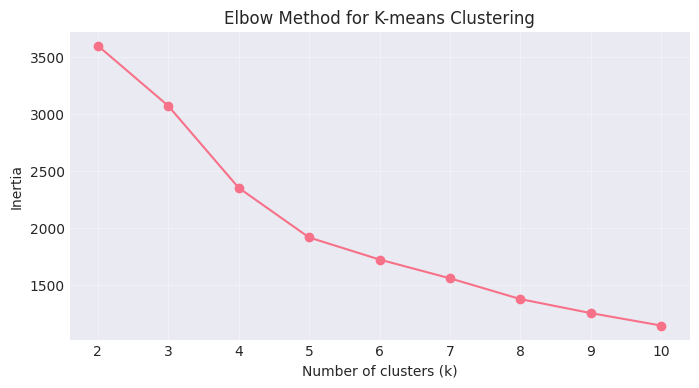

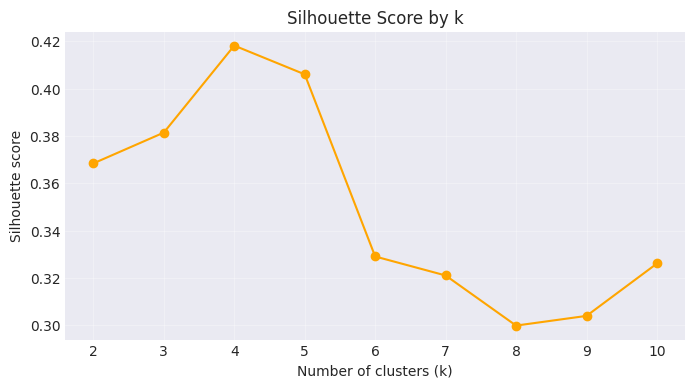

In [969]:
# K-means clustering on merged_df with elbow method
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Select numerical columns for clustering
cluster_cols = merged_df.columns.difference(['filename', 'us'])
cluster_cols = [col for col in cluster_cols if col in merged_df.columns]

# Build clustering dataset and drop missing values
clustering_data = merged_df[cluster_cols].copy()
clustering_data = clustering_data.dropna()

scaler = StandardScaler()
X = scaler.fit_transform(clustering_data)

# Elbow method: compute inertia for different k
inertia = []
ks = list(range(2, 11))
for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-means Clustering')
plt.grid(True, alpha=0.3)
plt.show()

# Optional silhouette score for k choices
silhouette_scores = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8, 4))
plt.plot(ks, silhouette_scores, marker='o', color='orange')
plt.xticks(ks)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by k')
plt.grid(True, alpha=0.3)
plt.show()



In [973]:
# Choose k from the elbow plot (change this value after inspection)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
merged_df.loc[clustering_data.index, 'kmeans_cluster'] = cluster_labels

print('Cluster counts:')
print(merged_df['kmeans_cluster'].value_counts())

if len(set(cluster_labels)) > 1:
    score = silhouette_score(X, cluster_labels)
    print(f'Silhouette score: {score:.3f}')

cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_cols
)
cluster_centers['cluster'] = range(n_clusters)
print('\nCluster centers:')
print(cluster_centers)


Cluster counts:
kmeans_cluster
2.0    188
0.0    185
3.0     29
1.0     15
Name: count, dtype: int64
Silhouette score: 0.418

Cluster centers:
      U [V]  Z1 []  amplitude  centroid_frequency     counts  duration  \
0  2.827228    0.0   0.034138        40688.840464   9.821622  0.000137   
1  2.733837    0.0   0.027093        60942.608535   5.133333  0.000063   
2  0.654400    0.0   0.061781       295968.126893   5.005319  0.000024   
3  0.509703    0.0   0.185816       285235.282202  17.448276  0.000114   

         energy  peak_frequency  ratio_1208_1604kHz  ratio_1604_2000kHz  \
0  6.788741e-08    23801.801802            0.000002        1.003189e-06   
1  3.619306e-08    23333.333333            0.000054        3.313362e-05   
2  1.850543e-08   141453.900709            0.000004        1.801548e-06   
3  1.465360e-07    69425.287356            0.000001        6.237416e-07   

   ratio_20_416kHz  ratio_416_812kHz  ratio_812_1208kHz  rise_time  cluster  
0         0.978321          0.01

Cluster 0.0: 5 files
['rawAE_1_33038898100.csv', 'rawAE_1_37150343600.csv', 'rawAE_1_38693054800.csv', 'rawAE_1_37626346600.csv', 'rawAE_1_38363643700.csv']
Cluster 1.0: 5 files
['rawAE_1_37292106900.csv', 'rawAE_1_38693295800.csv', 'rawAE_1_2768127900.csv', 'rawAE_1_39626809200.csv', 'rawAE_1_37153905000.csv']
Cluster 2.0: 5 files
['rawAE_1_59056795700.csv', 'rawAE_1_39170479000.csv', 'rawAE_1_781887100.csv', 'rawAE_1_646978500.csv', 'rawAE_1_5598390500.csv']
Cluster 3.0: 5 files
['rawAE_1_48360368400.csv', 'rawAE_1_6640717500.csv', 'rawAE_1_2767877300.csv', 'rawAE_1_22584967400.csv', 'rawAE_1_1345162100.csv']


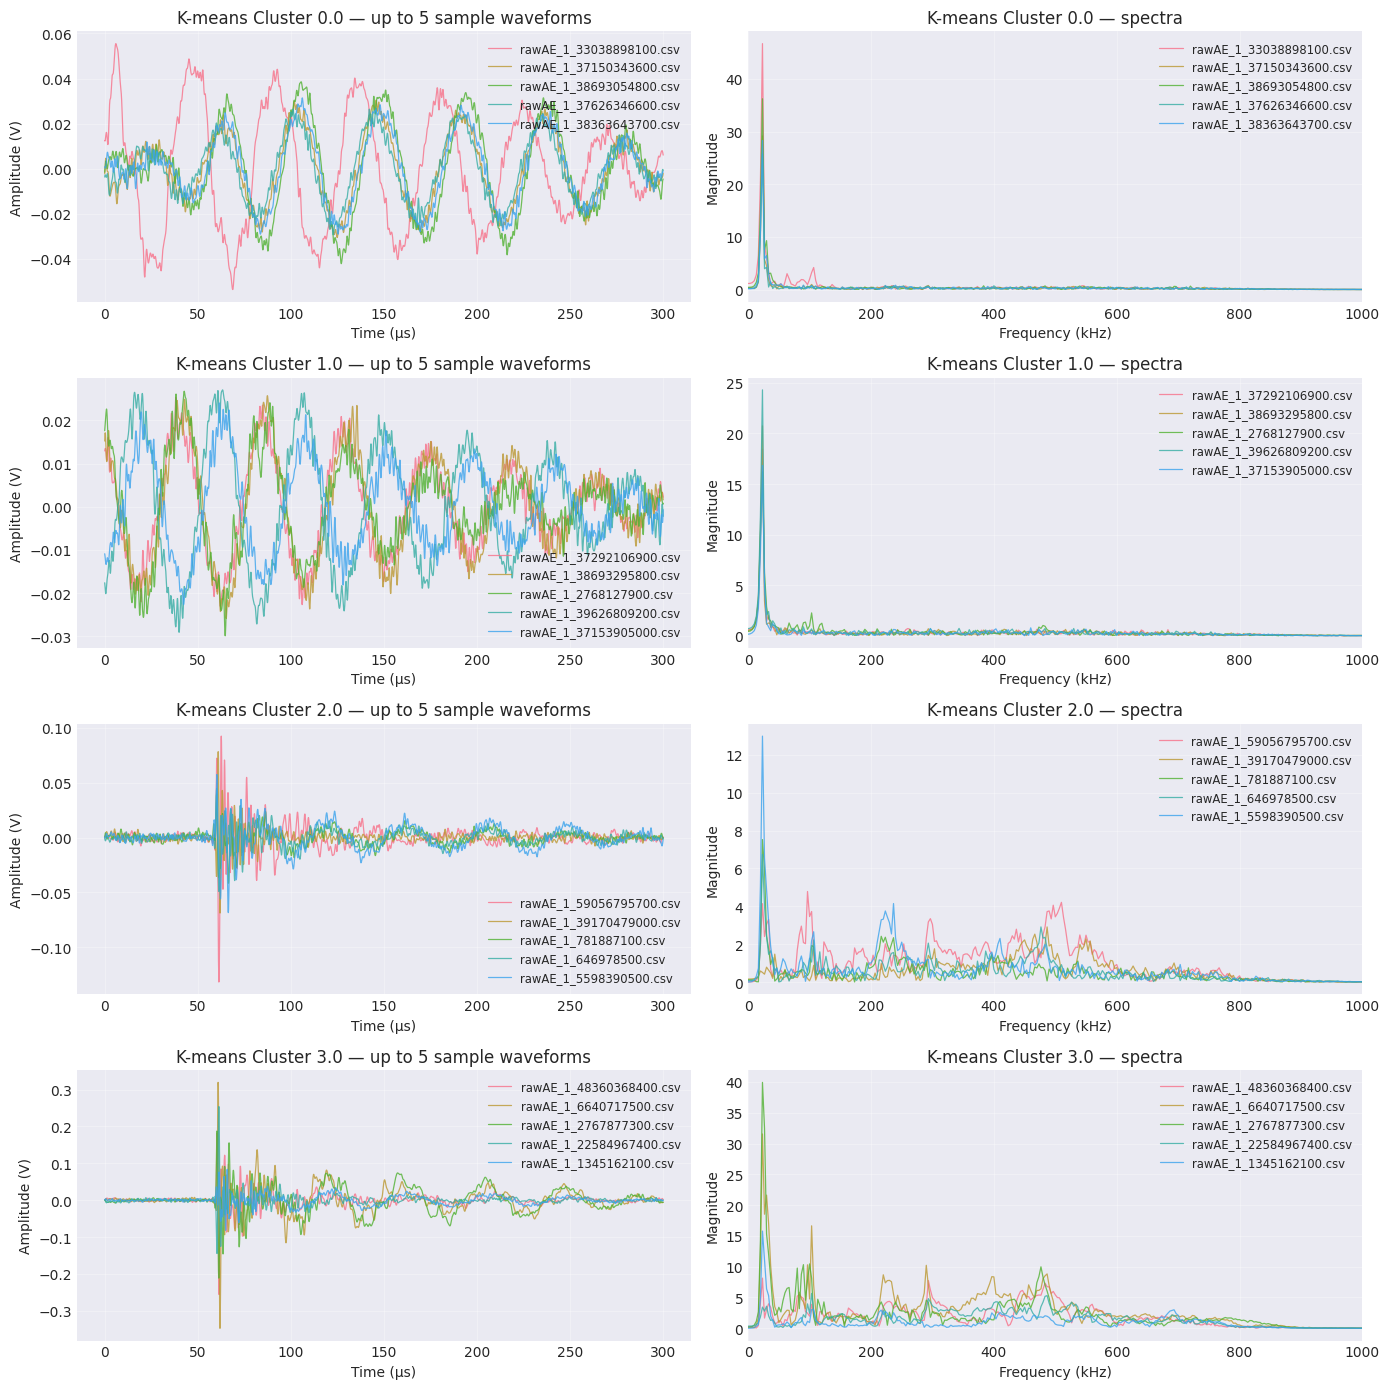

In [974]:
# Plot 5 waveform samples per k-means cluster from merged_df
sampled_filenames = {}
for cluster, group in merged_df.groupby('kmeans_cluster', sort=True):
    sampled = group.sample(n=min(5, len(group)), random_state=42)
    sampled_filenames[cluster] = sampled['filename'].tolist()
    print(f"Cluster {cluster}: {len(sampled_filenames[cluster])} files")
    print(sampled_filenames[cluster])

# Plot one figure with n_clusters rows and 2 columns: left = up to 5 overlaid time-series, right = their spectra
n_clusters = len(sampled_filenames)
if n_clusters == 0:
    print('No K-means clusters with samples to plot.')
else:
    fig, axes = plt.subplots(n_clusters, 2, figsize=(14, 3.5 * n_clusters), squeeze=False)

    for row_idx, (cluster, filenames) in enumerate(sampled_filenames.items()):
        ax_ts = axes[row_idx, 0]
        ax_f = axes[row_idx, 1]

        if len(filenames) == 0:
            ax_ts.axis('off')
            ax_f.axis('off')
            continue

        for filename in filenames:
            wf = waveforms_d1.get(filename)
            if wf is None:
                continue
            t = np.asarray(wf['time'])
            x = np.asarray(wf['amplitude'])
            time_us = t * 1e6

            # plot time-series (left) — overlay up to 5
            ax_ts.plot(time_us, x, alpha=0.8, linewidth=0.9, label=filename)

            # plot spectrum (right)
            dt = np.mean(np.diff(t)) if len(t) > 1 else 1.0
            fs = 1.0 / dt
            freqs = rfftfreq(len(x), d=1 / fs)
            spec = np.abs(rfft(x))
            ax_f.plot(freqs / 1e3, spec, alpha=0.8, linewidth=0.9, label=filename)

        ax_ts.set_title(f'K-means Cluster {cluster} — up to 5 sample waveforms')
        ax_ts.set_xlabel('Time (µs)')
        ax_ts.set_ylabel('Amplitude (V)')
        ax_ts.grid(True, alpha=0.3)
        ax_ts.legend(fontsize='small')

        ax_f.set_title(f'K-means Cluster {cluster} — spectra')
        ax_f.set_xlabel('Frequency (kHz)')
        ax_f.set_ylabel('Magnitude')
        ax_f.set_xlim(0, 1e6 / 1e3)  # up to 1 MHz
        ax_f.grid(True, alpha=0.3)
        ax_f.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

DBSCAN labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Cluster counts:
dbscan_cluster
 3.0    156
 0.0    140
-1.0     85
 1.0     18
 2.0      6
 5.0      6
 4.0      6
Name: count, dtype: int64
Cluster -1.0: 5 files
['rawAE_1_56366396500.csv', 'rawAE_1_23029800.csv', 'rawAE_1_49053851700.csv', 'rawAE_1_11050389900.csv', 'rawAE_1_3843348300.csv']
Cluster 0.0: 5 files
['rawAE_1_10753406400.csv', 'rawAE_1_3888370500.csv', 'rawAE_1_1103724500.csv', 'rawAE_1_14890524300.csv', 'rawAE_1_1606154100.csv']
Cluster 1.0: 5 files
['rawAE_1_385568100.csv', 'rawAE_1_835190600.csv', 'rawAE_1_7732387500.csv', 'rawAE_1_4254753700.csv', 'rawAE_1_3584639800.csv']
Cluster 2.0: 5 files
['rawAE_1_13351332900.csv', 'rawAE_1_15767551200.csv', 'rawAE_1_35772175300.csv', 'rawAE_1_16048596200.csv', 'rawAE_1_23352615900.csv']
Cluster 3.0: 5 files
['rawAE_1_37703880500.csv', 'rawAE_1_37444410800.csv', 'rawAE_1_37555558300.csv', 'rawAE_1_37503532600.csv', 'rawAE

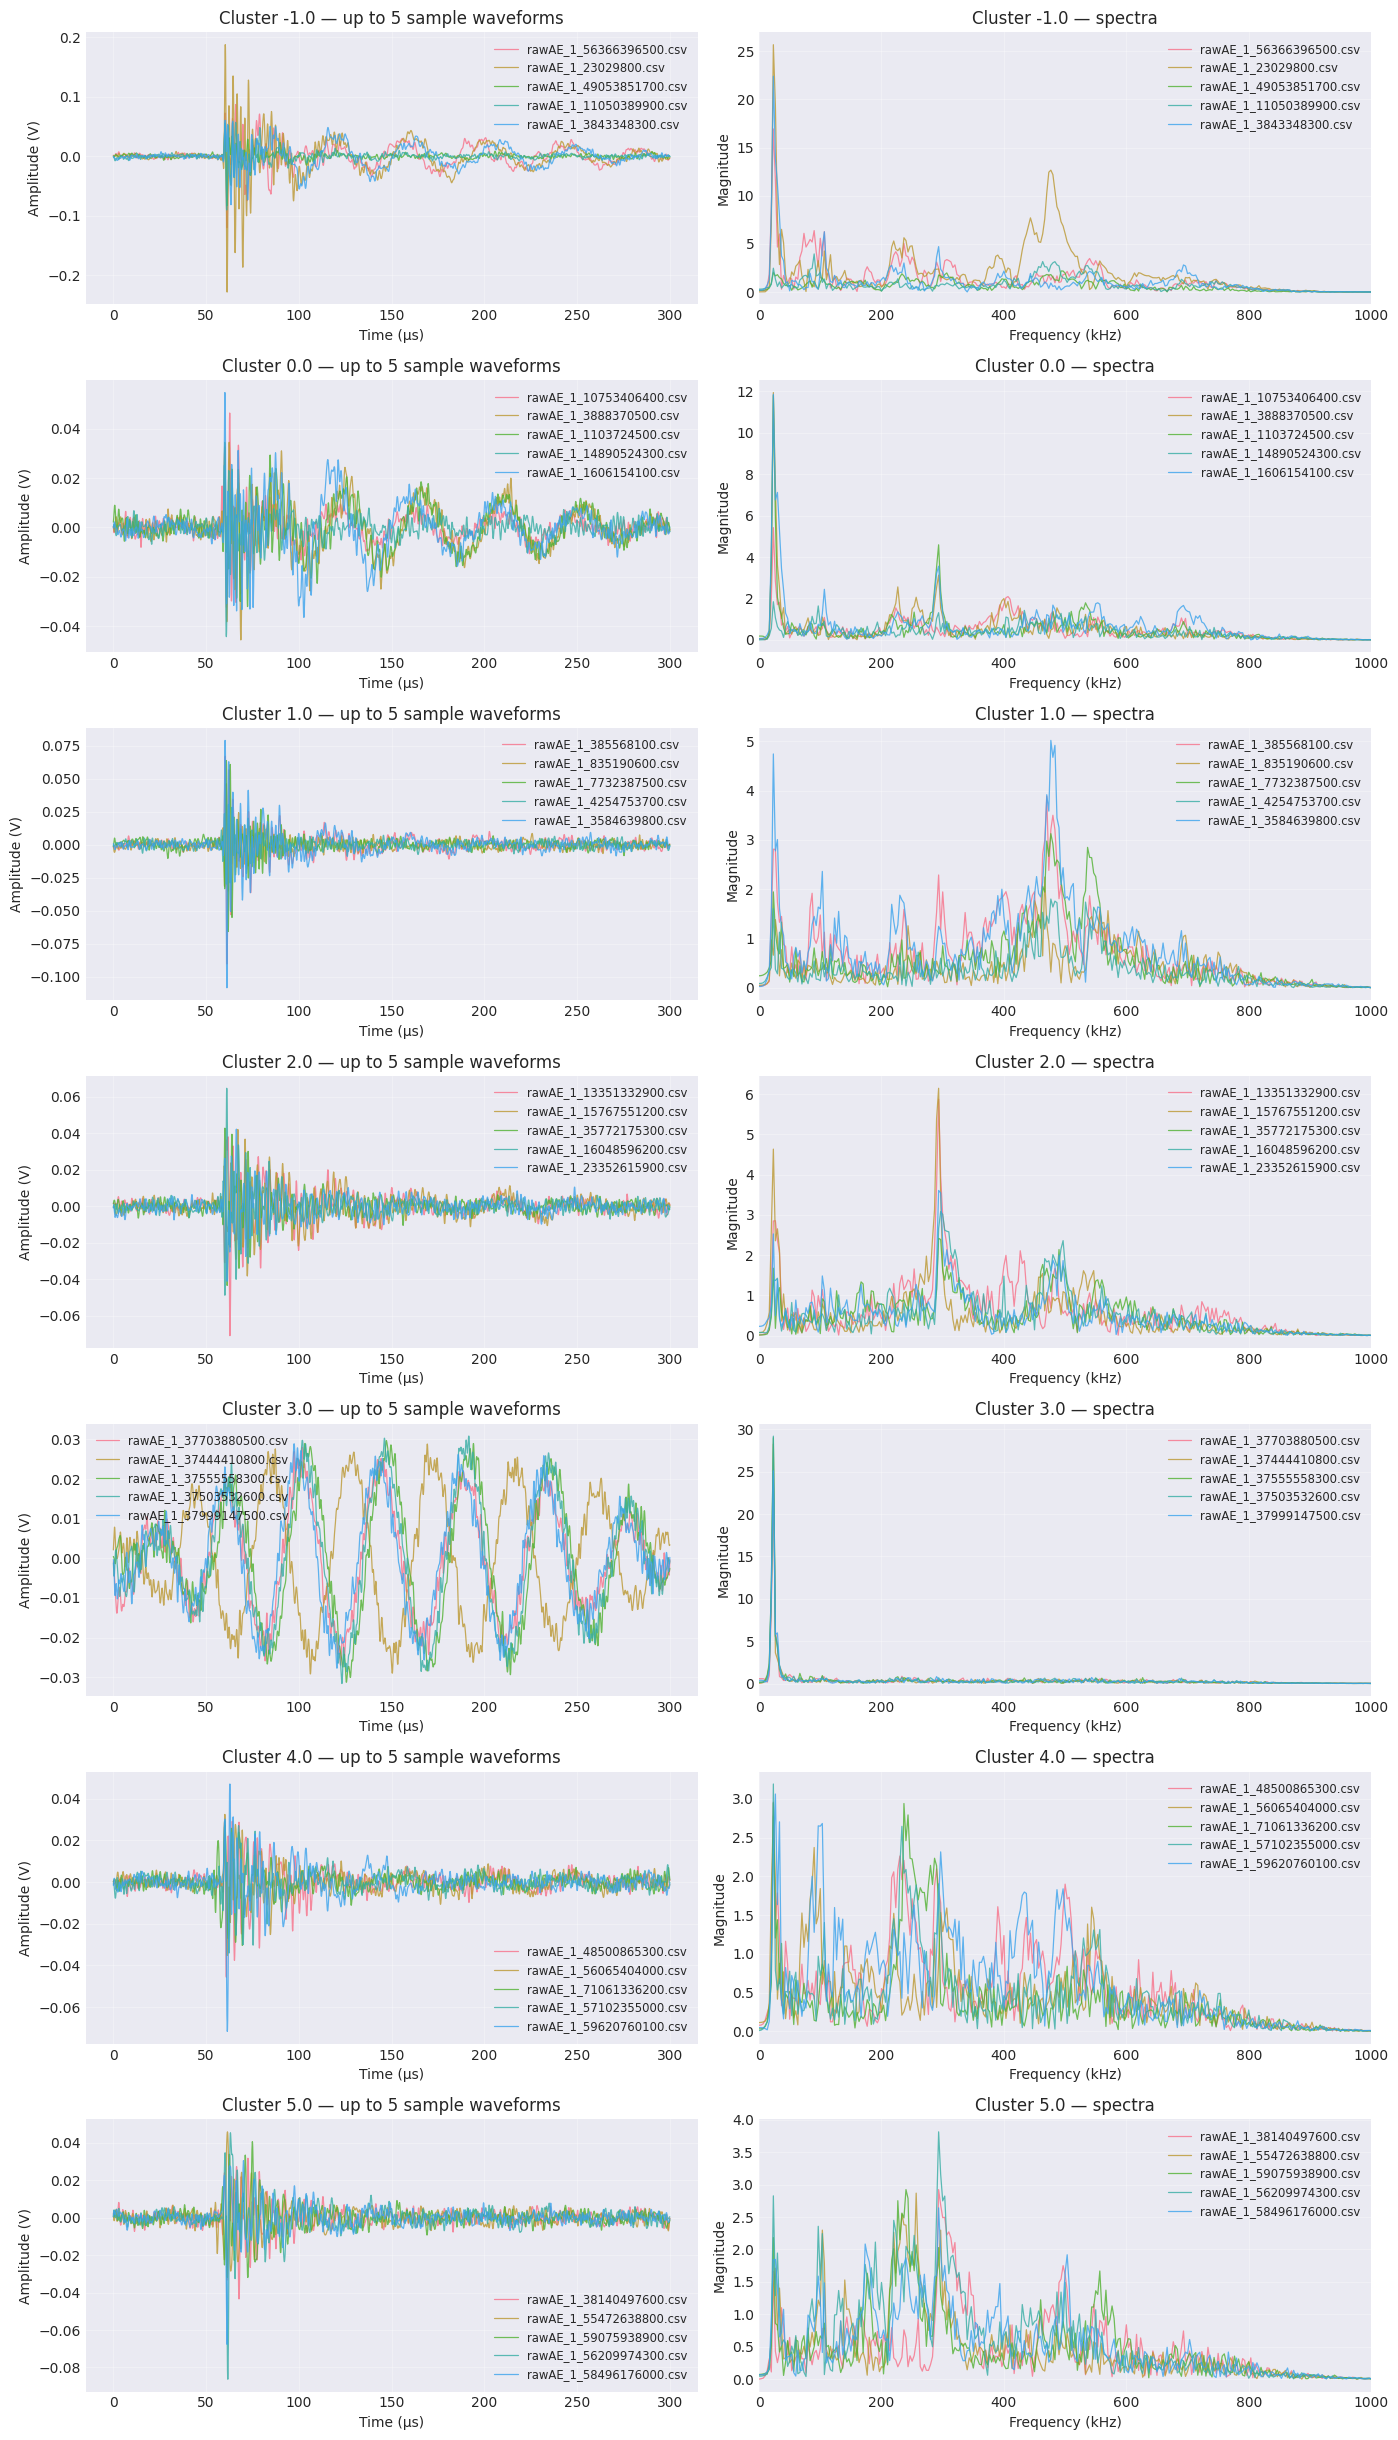

In [975]:
# DBSCAN clustering on merged_df and sample waveform plots (with FFT spectrum)
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.fft import rfft, rfftfreq

# Prepare clustering features
cluster_cols = merged_df.columns.difference(['filename', 'us', 'kmeans_cluster', 'TT [h]'])
cluster_cols = [col for col in cluster_cols if col in merged_df.columns]
clustering_data = merged_df[cluster_cols].copy().dropna()

scaler = StandardScaler()
X = scaler.fit_transform(clustering_data)

# DBSCAN parameters
dbscan = DBSCAN(eps=1.2, min_samples=5, metric='euclidean')
labels = dbscan.fit_predict(X)
merged_df.loc[clustering_data.index, 'dbscan_cluster'] = labels

unique_labels = sorted(set(labels))
print('DBSCAN labels:', unique_labels)
print('Cluster counts:')
print(merged_df['dbscan_cluster'].value_counts())

# Sample file names per DBSCAN cluster
sampled_filenames = {}
for cluster, group in merged_df.groupby('dbscan_cluster', sort=True):
    sample_count = min(5, len(group))
    sampled = group.sample(n=sample_count, random_state=42)
    sampled_filenames[cluster] = sampled['filename'].tolist()
    print(f"Cluster {cluster}: {len(sampled_filenames[cluster])} files")
    print(sampled_filenames[cluster])

# Plot one figure with n_clusters rows and 2 columns: left = up to 5 overlaid time-series, right = their spectra
n_clusters = len(sampled_filenames)
if n_clusters == 0:
    print('No DBSCAN clusters with samples to plot.')
else:
    fig, axes = plt.subplots(n_clusters, 2, figsize=(14, 3.5 * n_clusters), squeeze=False)

    for row_idx, (cluster, filenames) in enumerate(sampled_filenames.items()):
        ax_ts = axes[row_idx, 0]
        ax_f = axes[row_idx, 1]

        if len(filenames) == 0:
            ax_ts.axis('off')
            ax_f.axis('off')
            continue

        for filename in filenames:
            wf = waveforms_d1.get(filename)
            if wf is None:
                continue
            t = np.asarray(wf['time'])
            x = np.asarray(wf['amplitude'])
            time_us = t * 1e6

            # plot time-series (left) — overlay up to 5
            ax_ts.plot(time_us, x, alpha=0.8, linewidth=0.9, label=filename)

            # plot spectrum (right)
            dt = np.mean(np.diff(t)) if len(t) > 1 else 1.0
            fs = 1.0 / dt
            freqs = rfftfreq(len(x), d=1 / fs)
            spec = np.abs(rfft(x))
            ax_f.plot(freqs / 1e3, spec, alpha=0.8, linewidth=0.9, label=filename)

        ax_ts.set_title(f'Cluster {cluster} — up to 5 sample waveforms')
        ax_ts.set_xlabel('Time (µs)')
        ax_ts.set_ylabel('Amplitude (V)')
        ax_ts.grid(True, alpha=0.3)
        ax_ts.legend(fontsize='small')

        ax_f.set_title(f'Cluster {cluster} — spectra')
        ax_f.set_xlabel('Frequency (kHz)')
        ax_f.set_ylabel('Magnitude')
        ax_f.set_xlim(0, 1e6 / 1e3)  # up to 1 MHz
        ax_f.grid(True, alpha=0.3)
        ax_f.legend(fontsize='small')

    plt.tight_layout()
    plt.show()